In [1]:

import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak 
import os
import sys
import pandas as pd
import copy
from IPython.display import clear_output
# Get the path of the current notebook
current_dir = os.path.dirname(os.path.abspath(''))
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))

# Add the desired folder to sys.path
python_folder = os.path.join(current_dir, 'python')
run_folder = os.path.join(parent_dir, 'run')

sys.path.append(python_folder)
sys.path.append(run_folder)

from RunManager import RunManager
from Geant4Analyzer import Geant4Analyzer

In [11]:
manager = RunManager("/data/xenon/edecleen/master/G4Sim/run/rundb.json")
pd.options.display.max_rows = 1000
manager.display_all_runs()

,id,particle,ion,energy,fastSimulation,maxScatters,maxEnergy,sourceVolume,outputDir,outputFile,numEvents,numJobs,randomSeed,settingsFile,status,source position,geo description
0,run_01,geantino,None,1. MeV,true,1,1.1 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241113_1...,fast,1000000,1,994651,settings.json,active,"(0., 0., 0.) cm",geometry from paper
1,run_02,gamma,None,1. MeV,false,-999,-1.0 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241113_1...,std,1000000,1,686459,settings.json,active,"(0., 0., 0.) cm",geometry from paper
2,run_03,gamma,None,1. MeV,false,-999,-1.0 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241113_1...,std,1000000,1,648697,settings.json,active,"(0., 0., 0.) cm",geometry from paper
3,run_04,geantino,None,1. MeV,true,1,1.1 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241113_1...,fast,1000000,1,926103,settings.json,active,"(0., 0., 0.) cm",geometry from paper
4,run_05,geantino,None,1. MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241113_1...,fast,1000000,1,559452,settings.json,active,"(0., 0., 0.) cm",geometry from paper
5,run_06,geantino,None,1.5 MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241114_1...,fast,10000,1,322183,settings.json,active,"(0., 0., 0.) cm",geometry from paper
6,run_07,geantino,None,1.5 MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241114_1...,fast,10000,1,727743,settings.json,active,"(0., 0., 0.) cm",geometry from paper
7,run_08,geantino,None,1.5 MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241114_1...,fast,10000,1,289582,settings.json,active,"(0., 0., 0.) cm",geometry from paper
8,run_09,geantino,None,1.5 MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241114_1...,fast,10000,1,929708,settings.json,active,"(0., 0., 0.) cm",geometry from paper
9,run_10,geantino,None,1.5 MeV,true,1,0.25 MeV,InnerCryostat,/data/xenon/edecleen/master/data_ez/20241114_1...,fast,10000,1,26207,settings.json,active,"(0., 0., 0.) cm",geometry from paper


In [4]:

file = uproot.open(manager.get_output_root_files("run_221")[0])
#fast
file = uproot.open(manager.get_output_root_files("run_248")[0])
file2 = uproot.open(manager.get_output_root_files("run_252")[0])
gp = file["gam"]
ev = file["ev"].arrays()


In [5]:
energy=gp["e"].array()
att=gp["att"].array()
mat=gp["mat"].array()
proc=gp["proc"].array()


# print unique values from mat array
print(np.unique(mat))


['G4_AIR', 'G4_Cu', 'G4_Pb', ..., 'PTFE', 'StainlessSteel', 'Vacuum']


['compton' 'phot' 'tot' 'pair']


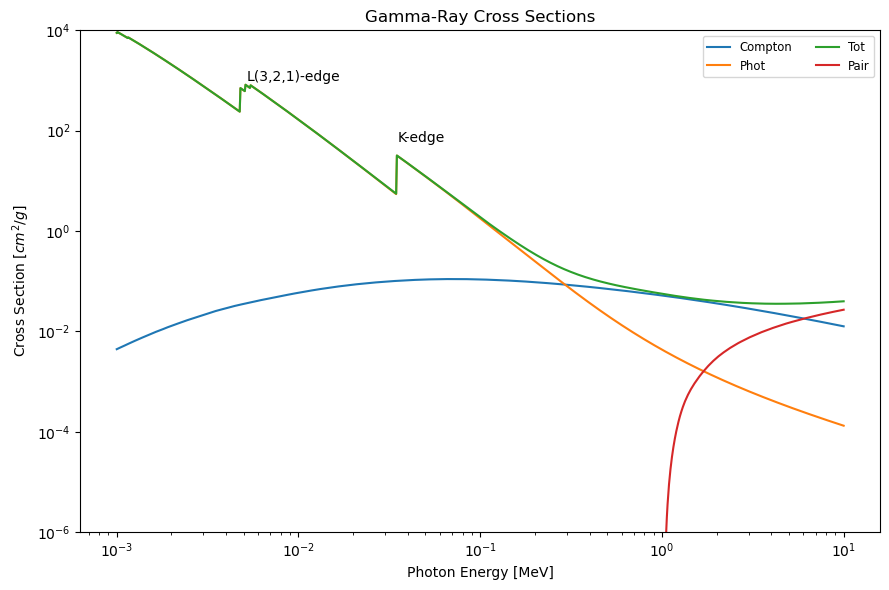

In [6]:
mat_str  = mat
proc_str = proc

# Put all data into a DataFrame
df = pd.DataFrame({
    "energy": energy,         # MeV
    "value":  att,            # either cross section (barn) or attenuation length (cm)
    "material": mat_str,
    "process": proc_str
})

# Separate the processes
cross_section_df = df[df["process"].isin(["compton", "phot", "tot", "pair"])]
attenuation_df   = df[df["process"] == "att"]

###############################################################################
# 1) PLOT CROSS SECTIONS (barn) FOR compton, phot, tot
###############################################################################
plt.figure(figsize=(9,6))

# Unique materials and processes
materials = cross_section_df["material"].unique()
processes = cross_section_df["process"].unique()
print(processes)
# Plot each material+process combination
for m in materials:
    if m == "LXe":
        for p in processes:
            subset = cross_section_df[(cross_section_df["material"] == m) & 
                                    (cross_section_df["process"] == p)]
            if len(subset) == 0:
                continue
            # Sort by energy for a smoother curve
            subset = subset.sort_values("energy")
            xenon_weight = 2.1801714e-22
            # initial barn/atom
            # atom to gram conversion
            subset["value"] = subset["value"] / xenon_weight
            # barns to cm2 conversion
            subset["value"] = subset["value"] * 1e-24
     
            # Plot cross section vs. energy
            plt.plot(subset["energy"], subset["value"] , label=f"{str.capitalize(p)}")

# Add vertical lines for Xenon edges (in MeV)
K_EDGE  = 0.03456  # 34.56 keV -> MeV
L3_EDGE = 0.00478  # 4.78  keV -> MeV
L2_EDGE = 0.00510  # 5.10  keV -> MeV
L1_EDGE = 0.00545  # 5.45  keV -> MeV


# Add text labels near the lines
plt.text(K_EDGE*1.02, 6e1,  "K-edge",  color='k')

plt.text(L1_EDGE*0.95, 1e3, "L(3,2,1)-edge", color='k')


plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-6, 1e4)
plt.xlabel("Photon Energy [MeV]")
plt.ylabel(r"Cross Section [$cm^2/g$]")
plt.legend(fontsize="small", ncol=2)
plt.title("Gamma-Ray Cross Sections")
plt.tight_layout()
plt.show()



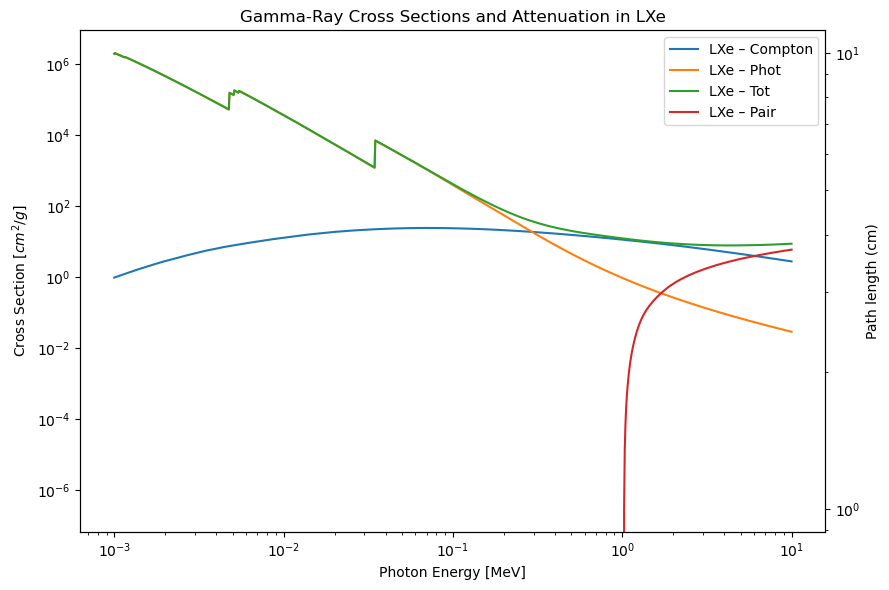

In [7]:

plt.figure(figsize=(9,6))

ax1 = plt.gca()  # Primary axis for cross sections

# 1. Plot CROSS SECTIONS on ax1
materials = cross_section_df["material"].unique()
processes = cross_section_df["process"].unique()

for m in materials:
    if m == "LXe":
        for p in processes:
            subset = cross_section_df[
                (cross_section_df["material"] == m) &
                (cross_section_df["process"] == p)
            ]
            if len(subset) == 0:
                continue
            
            # Sort by energy
            subset = subset.sort_values("energy")
            
            # Plot cross sections vs. energy
            ax1.plot(
                subset["energy"],
                subset["value"],            # Already converted to cm^2/g
                label=f"{m} – {p.capitalize()}"
            )

# 2. Overlay ATTENUATION data on a secondary y‐axis
ax2 = ax1.twinx()  # Secondary axis for attenuation
df_xenon = attenuation_df[attenuation_df["material"] == "LXe"].copy()
df_xenon = df_xenon.sort_values("energy")

# ax2.plot(
#     df_xenon["energy"],
#     df_xenon["value"],              # e.g. attenuation length or coefficient
#     color='black', linestyle='--',
#     label="Attenuation"
# )

# 3. Set scales, labels, legend
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_yscale("log")

ax1.set_xlabel("Photon Energy [MeV]")
ax1.set_ylabel(r"Cross Section [$cm^2/g$]")
ax2.set_ylabel("Path length (cm)")  # e.g. "cm" if it's a mean free path

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Gamma-Ray Cross Sections and Attenuation in LXe")
plt.tight_layout()
plt.show()

In [15]:
# std_nobrem run
file_neutron_xsec = uproot.open(manager.get_output_root_files("run_386")[0])

gp = file_neutron_xsec["neutron"]


In [16]:
energy=gp["e"].array()
att=gp["att"].array()
mat=gp["mat"].array()
proc=gp["proc"].array()


# print unique values from mat array
print(np.unique(mat))

['G4_AIR', 'G4_Cu', 'G4_Pb', ..., 'PTFE', 'StainlessSteel', 'Vacuum']


['elas' 'inelas' 'ncap' 'fiss' 'tot']


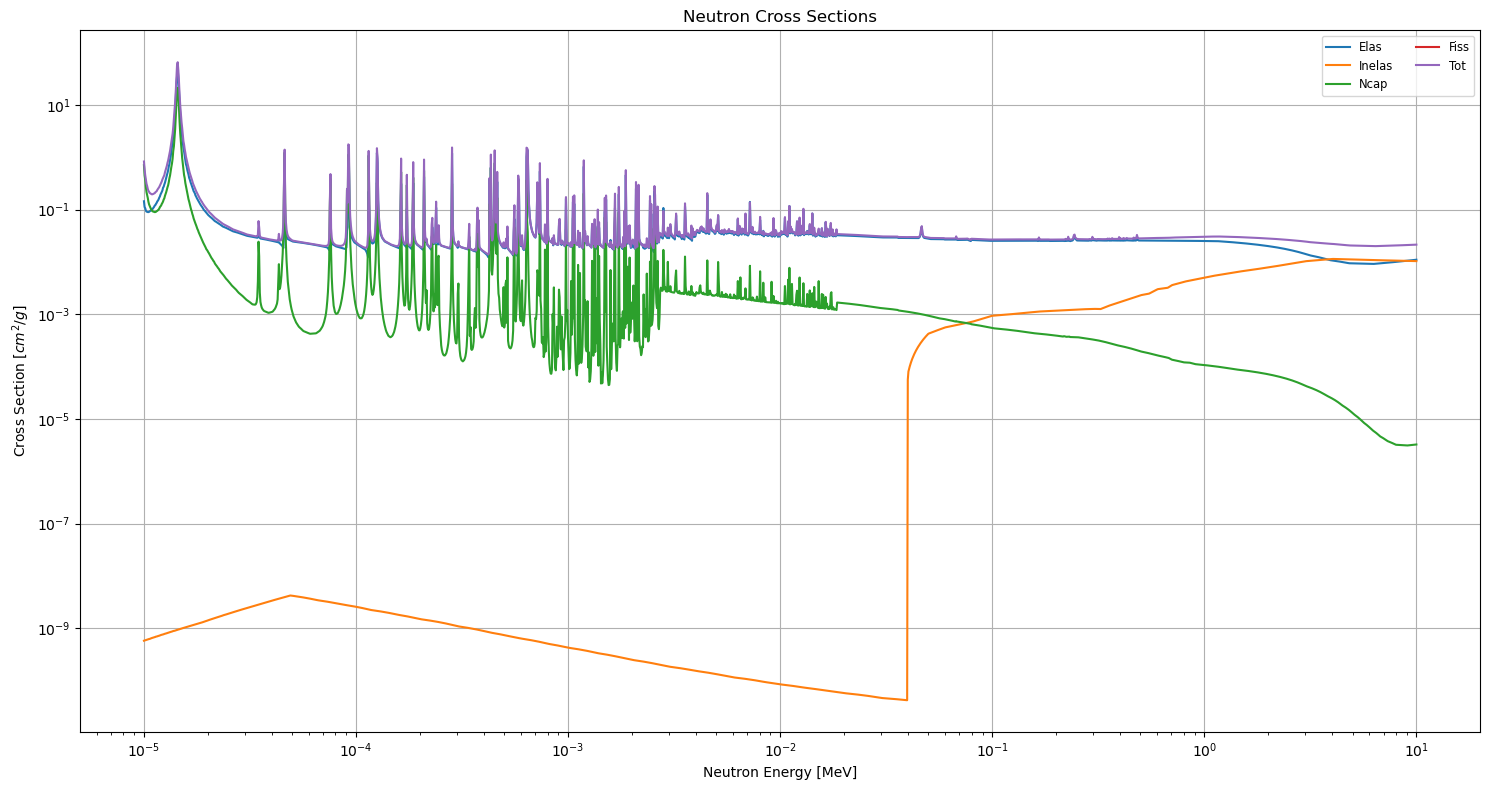

In [19]:
mat_str  = mat
proc_str = proc

# Put all data into a DataFrame
df = pd.DataFrame({
    "energy": energy,         # MeV
    "value":  att,            # either cross section (barn) or attenuation length (cm)
    "material": mat_str,
    "process": proc_str
})

# Separate the processes
cross_section_df = df[df["process"].isin(["elas", "inelas","ncap","fiss", "tot" ])]
attenuation_df   = df[df["process"] == "att"]

###############################################################################
# 1) PLOT CROSS SECTIONS (barn) FOR compton, phot, tot
###############################################################################
plt.figure(figsize=(15,8))

# Unique materials and processes
materials = cross_section_df["material"].unique()
processes = cross_section_df["process"].unique()
print(processes)
# Plot each material+process combination
for m in materials:
    if m == "LXe":
        for p in processes:
            subset = cross_section_df[(cross_section_df["material"] == m) & 
                                    (cross_section_df["process"] == p)]
            if len(subset) == 0:
                continue
            # Sort by energy for a smoother curve
            subset = subset.sort_values("energy")
            xenon_weight = 2.1801714e-22
            # initial barn/atom
            # atom to gram conversion
            subset["value"] = subset["value"] / xenon_weight
            # barns to cm2 conversion
            subset["value"] = subset["value"] * 1e-24
     
            # Plot cross section vs. energy
            plt.plot(subset["energy"], subset["value"] , label=f"{str.capitalize(p)}")

plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.xlabel("Neutron Energy [MeV]")
plt.ylabel(r"Cross Section [$cm^2/g$]")
plt.legend(fontsize="small", ncol=2)
plt.title("Neutron Cross Sections")
plt.tight_layout()
# set the x range of the plot
plt.show()


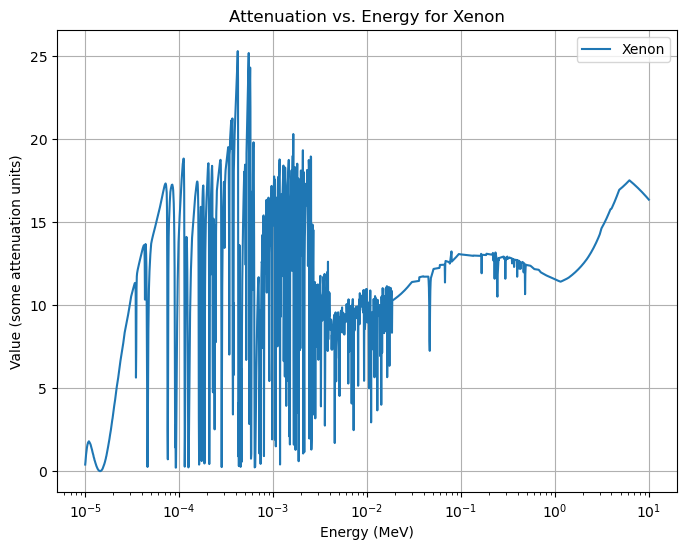

In [11]:

# Suppose 'attenuation_df' is your DataFrame with columns: 
# ['energy', 'value', 'material', 'process']

# 1. Filter for rows where the material is Xenon (assuming "G4_Xe" is the label)
df_xenon = attenuation_df[attenuation_df["material"] == "LXe"]

# 2. Plot energy vs. value
plt.figure(figsize=(8,6))
plt.plot(df_xenon["energy"], df_xenon["value"], label="Xenon")
plt.xscale("log")
# 3. Label axes and show the plot
plt.xlabel("Energy (MeV)")
plt.ylabel("Value (some attenuation units)")
plt.title("Attenuation vs. Energy for Xenon")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_klein_nishina(material, cosThetaMin, normalize=True):
    cut = (mat == material)
    y_values_z = kn[cut] * z[cut]
    y_values_ff = kn[cut] * ff[cut]
    cost_cut = cost[cut]

    if normalize:
        # Calculate normalization over the histogram range
        hist_min = cosThetaMin
        hist_max = 1.0
        mask = (cost_cut >= hist_min) & (cost_cut <= hist_max)
        
        area_z = np.trapz(y_values_z[mask], cost_cut[mask])
        area_ff = np.trapz(y_values_ff[mask], cost_cut[mask])
        y_values_z = y_values_z / area_z
        y_values_ff = y_values_ff / area_ff

    plt.plot(cost_cut, y_values_z, linestyle='--', color="black", label='Klein-Nishina')
    plt.plot(cost_cut, y_values_ff, linestyle='-', color="blue", label='Klein-Nishina + Form Factor')
    plt.xlabel("cos($\\theta$)")
    plt.ylabel("Normalized d$\sigma$/d$\Omega$ (a.u.)")
    plt.legend()

#### Function to Plot Histogram

def plot_hist(threshold=0.01, normalize=True):
    h = file['cost']
    bin_contents = h.values()
    bin_edges = h.axis().edges()
    bin_widths = np.diff(bin_edges)

    if normalize:
        area_hist = np.sum(bin_contents * bin_widths)
        bin_contents = bin_contents / area_hist

    
    # Find the first bin over the threshold
    cosTheta_min = None
    for content, edge in zip(bin_contents, bin_edges[:-1]):
        if content > threshold:
            cosTheta_min = edge
            break

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents, histtype='step', edgecolor='red', label='MC generated')
    plt.xlabel('$\\cos(\\theta)$')
    plt.ylabel('Normalized $dN / d\\cos(\\theta)$')
    plt.title('Compton scatter angles for Xe')
    plt.grid(True)
    plt.legend()
    
    return cosTheta_min


['ev;1', 'gam;1', 'neutron;1', 'proc_names;1', 'diff_xsec;1', 'cost;1', 'proc;1']
{'Process Name': array(['Transportation', 'nCapture'], dtype=object), 'Bin Index': array([1, 2], dtype=int32)}
dict_keys(['Process Name', 'Bin Index'])


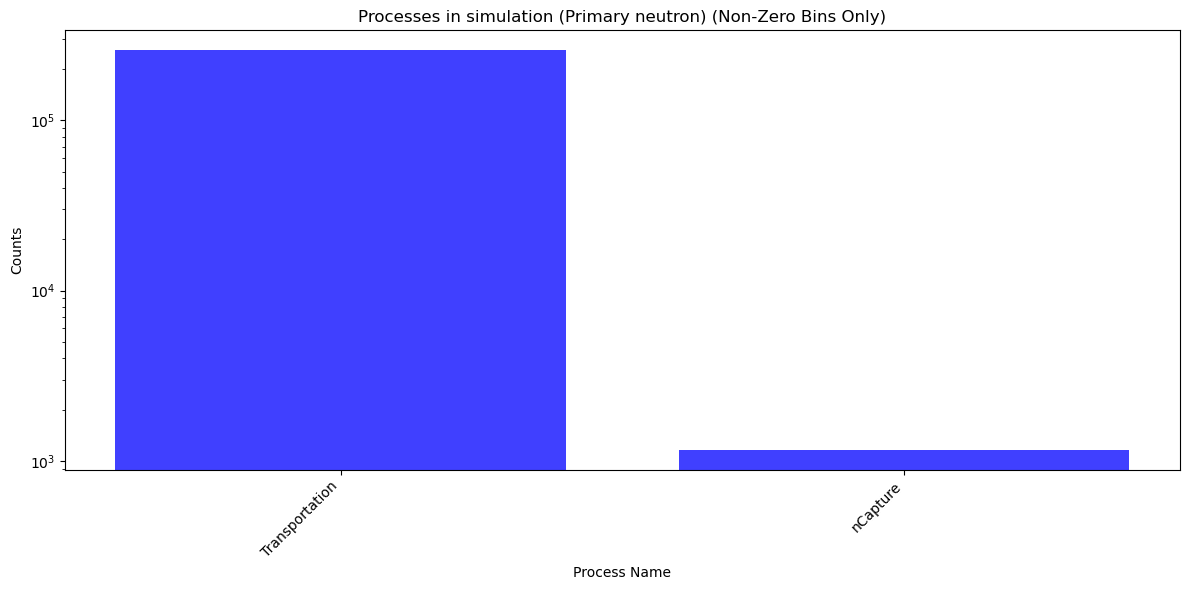

In [16]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 

# Open the ROOT file
# elastic only: run_394, inelastic: run_395, capture: run_396
file2 = uproot.open(manager.get_output_root_files("run_396")[0])
print(file2.keys())  # Print available trees

# Load histogram
hist = file2["proc"]
bin_counts = hist.values()
bin_edges = hist.axis().edges()

# Load process name mapping if available
if "proc_names" in file2:
    proc_data = file2["proc_names"].arrays(library="np")
    print(proc_data)
    print(proc_data.keys())
    # Convert to dictionary (check correct column names)
    process_map = dict(zip(proc_data["Bin Index"], proc_data["Process Name"]))
else:
    print("Warning: proc_names not found in ROOT file!")
    process_map = {}

# Get valid (non-zero) bins
nonzero_indices = np.where(bin_counts > 0)[0]
nonzero_counts = bin_counts[nonzero_indices]

# Assign labels (ensure correct bin mapping)
bin_labels = [process_map.get(int(bin_edges[i]), f"Unknown {int(bin_edges[i])}") for i in nonzero_indices]

# Plot non-zero bins only
plt.figure(figsize=(12, 6))
plt.bar(bin_labels, nonzero_counts, log=True, align='center', alpha=0.75, color="blue")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.xlabel("Process Name")
plt.ylabel("Counts")
plt.title("Processes in simulation (Primary neutron) (Non-Zero Bins Only)")
plt.tight_layout()

plt.show()

['ev;1', 'gam;1', 'neutron;1', 'proc_names;1', 'diff_xsec;1', 'cost;1', 'proc;1']
{'Process Name': array(['Transportation', 'hadElastic', 'ionIoni', 'NoProcess',
       'neutronInelastic', 'phot', 'msc', 'eIoni', 'Radioactivation',
       'compt', 'Rayl', 'nCapture', 'conv', 'annihil', 'eBrem', 'hIoni',
       'photonNuclear'], dtype=object), 'Bin Index': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
      dtype=int32)}
dict_keys(['Process Name', 'Bin Index'])


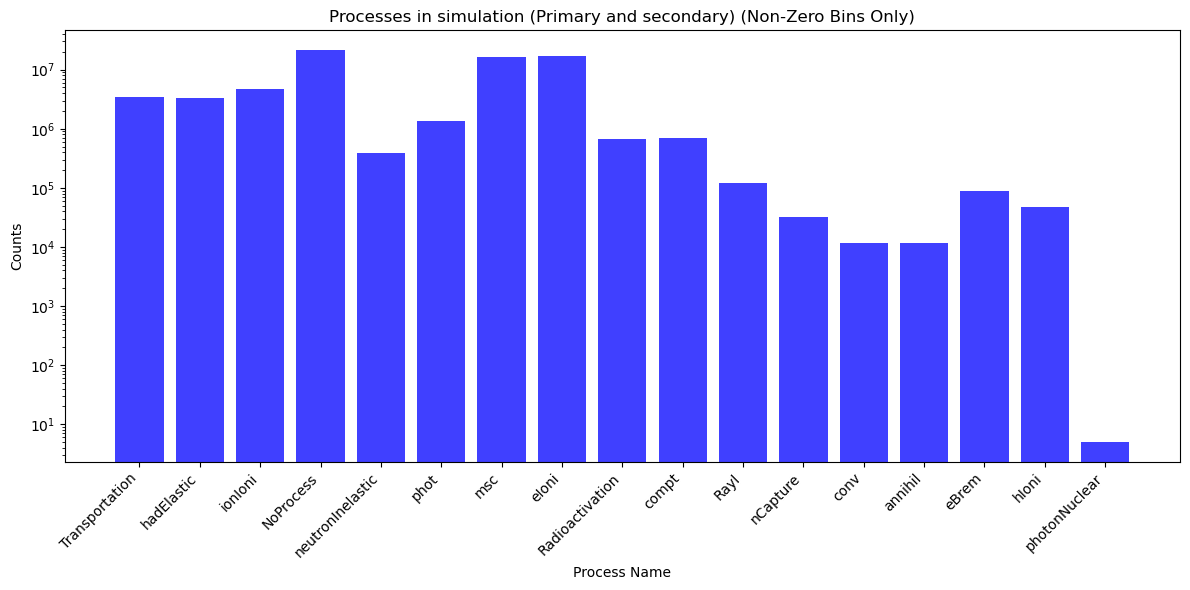

In [14]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 

# Open the ROOT file
file2 = uproot.open(manager.get_output_root_files("run_373")[0])
print(file2.keys())  # Print available trees

# Load histogram
hist = file2["proc"]
bin_counts = hist.values()
bin_edges = hist.axis().edges()

# Load process name mapping if available
if "proc_names" in file2:
    proc_data = file2["proc_names"].arrays(library="np")
    print(proc_data)
    print(proc_data.keys())
    # Convert to dictionary (check correct column names)
    process_map = dict(zip(proc_data["Bin Index"], proc_data["Process Name"]))
else:
    print("Warning: proc_names not found in ROOT file!")
    process_map = {}

# Get valid (non-zero) bins
nonzero_indices = np.where(bin_counts > 0)[0]
nonzero_counts = bin_counts[nonzero_indices]

# Assign labels (ensure correct bin mapping)
bin_labels = [process_map.get(int(bin_edges[i]), f"Unknown {int(bin_edges[i])}") for i in nonzero_indices]

# Plot non-zero bins only
plt.figure(figsize=(12, 6))
plt.bar(bin_labels, nonzero_counts, log=True, align='center', alpha=0.75, color="blue")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.xlabel("Process Name")
plt.ylabel("Counts")
plt.title("Processes in simulation (Primary and secondary) (Non-Zero Bins Only)")

plt.tight_layout()

plt.show()

In [3]:

cut_main = lambda data: (
    (data['ndet'][:, 0] + data['ndet'][:, 1] == 1) 
    
)

# Hit-level cut (for r and zh)
cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670)

fast = Geant4Analyzer("run_255", first_only=True)
normal = Geant4Analyzer("run_252", first_only=True)
fast.preprocess_data(cut=cut_main, cut_hit=cut_hit_main)
normal.preprocess_data(cut=cut_main, cut_hit=cut_hit_main)


Initialized Geant4Analyzer with run_id=run_255, label=
Loading data from /data/xenon/edecleen/master/data_ez/20250207_151752/fast_0.root
Loading /data/xenon/edecleen/master/data_ez/20250207_151752/fast_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250207_151752/fast_0.root']
Initialized Geant4Analyzer with run_id=run_252, label=
Loading data from /data/xenon/edecleen/master/data_ez/20250206_141738/std_0.root
Loading /data/xenon/edecleen/master/data_ez/20250206_141738/std_0.root


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f979c544c90>>
Traceback (most recent call last):
  File "/data/xenon/miniconda3/envs/g4/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250206_141738/std_0.root']


4348
integral standard= 4348.0
integral fast= 7740.579121460398


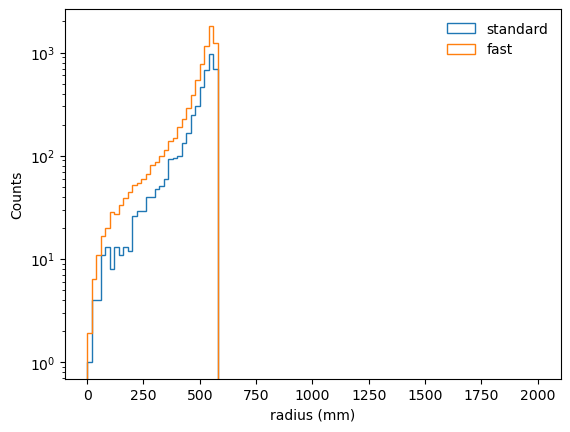

In [16]:
fig , ax = plt.subplots()
print(len(normal.data['r']))
normal.plot_histogram('r', bins=100, ax=ax,label="standard", show=True, range=(0, 2000 + 1))
fast.plot_histogram('r', bins=100, ax=ax,label="fast", show=True, range=(0, 2000 + 1))
#plt.hist(normal.data['eh'],bins=100,range=(0,750),histtype='step',label="Standard")
plt.yscale("log")
plt.show()

integral fast= 7740.579121460399
integral Standard= 4348.0


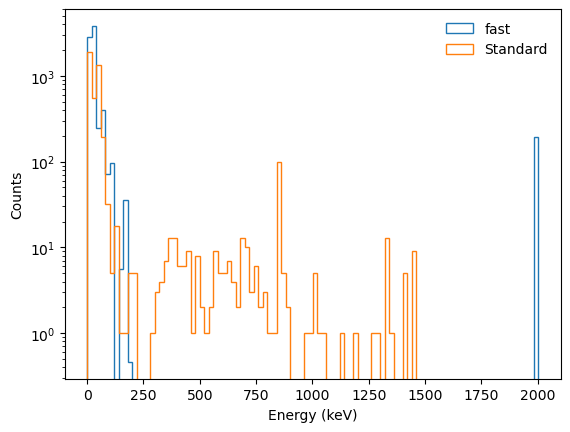

In [17]:
fig , ax = plt.subplots()

fast.plot_histogram('eh', bins=100, ax=ax,label="fast", show=True, range=(0, 2000 + 1))
normal.plot_histogram('eh', bins=100, ax=ax,label="Standard", show=True, range=(0, 2000 + 1))
#plt.hist(test.data['eh'],bins=100,range=(0,750),histtype='step',label="Standard")
plt.yscale("log")
plt.show()

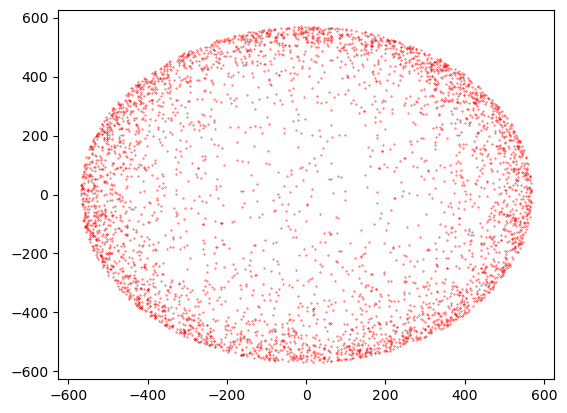

In [18]:
from XENONnTPlotter import XENONnTPlotter
geometry = fast.geometry
# plt.scatter(test.data['xh'],test.data['yh'],s=0.1, color='blue')
plt.scatter(normal.data['xh'],normal.data['yh'],s=0.1, color='red') 


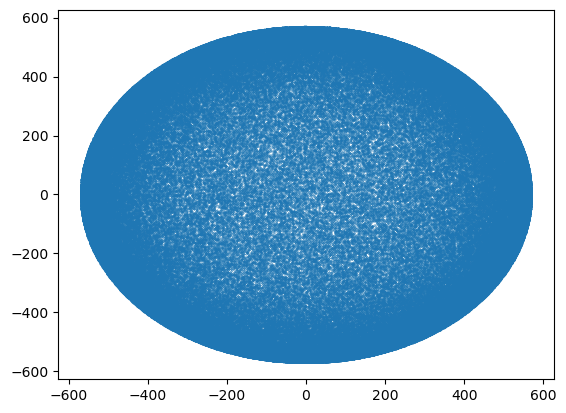

In [19]:
from XENONnTPlotter import XENONnTPlotter
geometry = fast.geometry

plt.scatter(fast.data['xh'],fast.data['yh'],s=0.1)

Initialized Geant4Analyzer with run_id=run_368, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root']
integral Only Elastic= 172346.0
integral Only Inelastic= 295622.0
integral Only Neutron capture= 1847.0
integral Total of events with only a single type of interaction= 472334.0
integral Elastic= 172196.0
integral Inelastic= 226769.0
integral Ncap= 112.0
integral Total= 399359.0


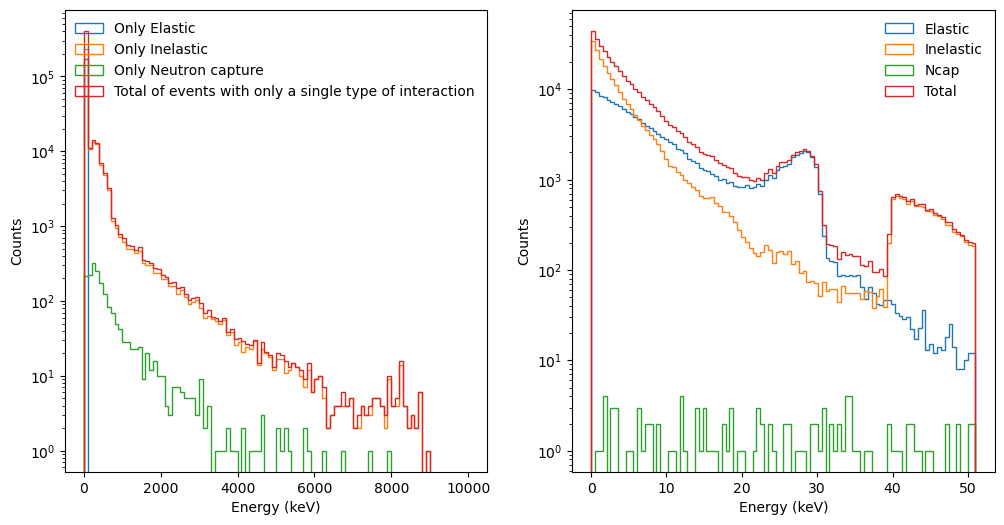

In [20]:

# ncap
# nelas
# ninelas



cut_main_inelas = lambda data: (
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] > 0) &
    ( data['ncap'][:, 0] + data['ncap'][:, 1] + data['nelas'][:, 0] + data['nelas'][:, 1]  == 0) &
    ## is direct
     (ak.values_astype(data['type'], int) & 3 == 1) 
)

cut_main_ncap = lambda data: (
    (data['ncap'][:, 0] + data['ninelas'][:, 1] > 0) &
    ( data['ninelas'][:, 0] + data['ninelas'][:, 1] + data['nelas'][:, 0] + data['nelas'][:, 1]  == 0) &
    ## is direct
     (ak.values_astype(data['type'], int) & 3 == 1) 
)

cut_main_elas = lambda data: (
    (data['nelas'][:, 0] + data['nelas'][:, 1] > 0) &
    (data['ncap'][:, 0] + data['ncap'][:, 1] + data['ninelas'][:, 0] + data['ninelas'][:, 1]  == 0) &
    ## is direct
     (ak.values_astype(data['type'], int) & 3 == 1) 
)


cut_main_total = lambda data: (
    (
        (
            ((data['nelas'][:, 0] + data['nelas'][:, 1]) > 0)
            & ((data['ncap'][:, 0] + data['ncap'][:, 1]
                + data['ninelas'][:, 0] + data['ninelas'][:, 1]) == 0)
        )
        | (
            ((data['ncap'][:, 0] + data['ncap'][:, 1]) > 0)
            & ((data['ninelas'][:, 0] + data['ninelas'][:, 1]
                + data['nelas'][:, 0] + data['nelas'][:, 1]) == 0)
        )
        | (
            ((data['ninelas'][:, 0] + data['ninelas'][:, 1]) > 0)
            & ((data['ncap'][:, 0] + data['ncap'][:, 1]
                + data['nelas'][:, 0] + data['nelas'][:, 1]) == 0)
        )
    )
    & ((ak.values_astype(data['type'], int) & 3) == 1)
)


cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670)

standard_neutron_1m = Geant4Analyzer("run_368", first_only=False)
normal2_elas = copy.deepcopy(standard_neutron_1m)
normal2_inelas = copy.deepcopy(standard_neutron_1m)
normal2_ncap = copy.deepcopy(standard_neutron_1m)
normal2_total = copy.deepcopy(standard_neutron_1m)


normal2_elas.preprocess_data(cut=cut_main_elas, cut_hit=cut_hit_main)
normal2_inelas.preprocess_data(cut=cut_main_inelas, cut_hit=cut_hit_main)
normal2_ncap.preprocess_data(cut=cut_main_ncap, cut_hit=cut_hit_main)
normal2_total.preprocess_data(cut=cut_main_total, cut_hit=cut_hit_main)

fig , ax = plt.subplots(1,2, figsize=(12,6))

normal2_elas.plot_histogram('eh', bins=100, ax=ax[0],label="Only Elastic cut", show=True, range=(0, 10000 + 1))
normal2_inelas.plot_histogram('eh', bins=100, ax=ax[0],label="Only Inelastic cut", show=True, range=(0, 10000 + 1))
normal2_ncap.plot_histogram('eh', bins=100, ax=ax[0],label="Only Neutron capture cut", show=True, range=(0, 10000 + 1))
normal2_total.plot_histogram('eh', bins=100, ax=ax[0],label="Total of events with only a single type of interaction", show=True, range=(0, 10000 + 1))

ax[0].set_yscale("log")

normal2_elas.plot_histogram('eh', bins=100, ax=ax[1],label="Elastic", show=True, range=(0, 50 + 1))
normal2_inelas.plot_histogram('eh', bins=100, ax=ax[1],label="Inelastic", show=True, range=(0, 50 + 1))
normal2_ncap.plot_histogram('eh', bins=100, ax=ax[1],label="Ncap", show=True, range=(0, 50 + 1))
normal2_total.plot_histogram('eh', bins=100, ax=ax[1],label="Total", show=True, range=(0, 50 + 1))

ax[1].set_yscale("log")
plt.show()

Initialized Geant4Analyzer with run_id=run_368, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250224_102127/std_0.root']
integral 1 inelastic scatter and non zero amount of elastic= 1136391.0
integral 1 inelastic and no elastic= 226769.0


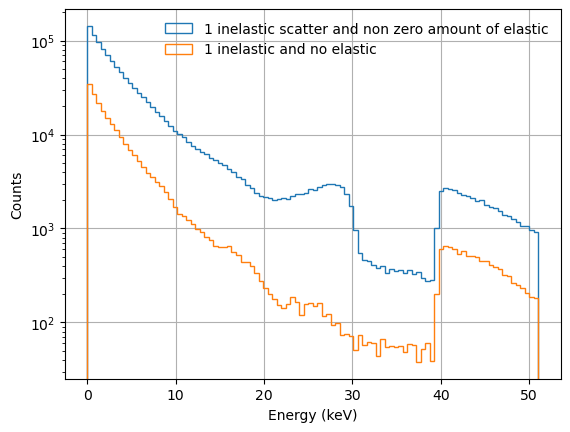

In [22]:
cut_ninelas_with_elas = lambda data: (
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] == 1) &
    (data['nelas'][:, 0] + data['nelas'][:, 1] > 0) &
    (data['ncap'][:, 0] + data['ncap'][:, 1] == 0) &
    
    ## is direct
     (ak.values_astype(data['type'], int) & 3 == 1) 
)

cut_ninelas_without_elas = lambda data: (
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] == 1) &
    (data['nelas'][:, 0] + data['nelas'][:, 1] == 0) &
    (data['ncap'][:, 0] + data['ncap'][:, 1] == 0) &
    ## is direct
     (ak.values_astype(data['type'], int) & 3 == 1) 
)


cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670)
standard_neutron_1m = Geant4Analyzer("run_368", first_only=False)

ninelas1 = copy.deepcopy(standard_neutron_1m)
ninelas2 = copy.deepcopy(standard_neutron_1m)


ninelas1.preprocess_data(cut=cut_ninelas_with_elas, cut_hit=cut_hit_main)
ninelas2.preprocess_data(cut=cut_ninelas_without_elas, cut_hit=cut_hit_main)

fig , axs = plt.subplots()

ninelas1.plot_histogram('eh', bins=100, ax=axs,label="1 inelastic scatter and non zero amount of elastic" , show=True, range=(0, 50 + 1))
ninelas2.plot_histogram('eh', bins=100, ax=axs,label="1 inelastic and no elastic" , show=True, range=(0, 50 + 1))

axs.grid(True)
axs.set_yscale("log")
plt.show()

Initialized Geant4Analyzer with run_id=run_394, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_8.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_9.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_2.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_5.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_4.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_1.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_3.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_0.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_7.root', '/data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_6.root']
Loading /data/xenon/edecleen/master/data_ez/20250227_105558/std_neutron_elastic_8.root
Loading /data/xenon

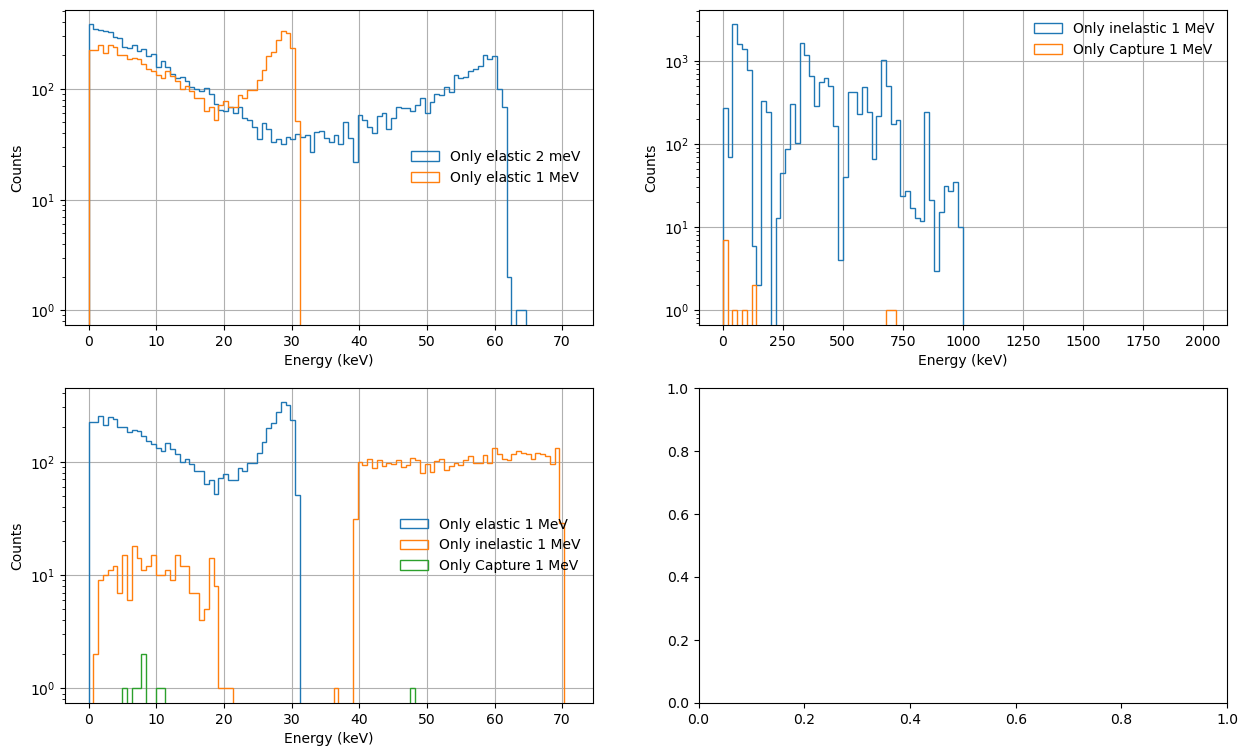

In [22]:

cut_main_elastic = lambda data: (
    (data['nelas'][:, 0] + data['nelas'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) &
    (ak.values_astype(data['type'], int) & 16 == 16)

    
)

cut_main_inelastic = lambda data: (
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
        
)

cut_main_ncap = lambda data: (
    (data['ncap'][:, 0] + data['ncap'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1)
   
)


cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670)

# 368 for 1 MeV source
elastic_neutron_1m = Geant4Analyzer("run_394", first_only=False)
elastic_neutron_2m = Geant4Analyzer("run_397", first_only=False)

inelastic_neutron_1m =  Geant4Analyzer("run_395", first_only=False)
capture_neutron_1m = Geant4Analyzer("run_396", first_only=False)


elastic_neutron_1m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_2m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)

inelastic_neutron_1m.preprocess_data(cut=cut_main_inelastic, cut_hit=cut_hit_main)
capture_neutron_1m.preprocess_data(cut=cut_main_ncap, cut_hit=cut_hit_main)

fig , axs = plt.subplots(2,2 , figsize=(15,9))

elastic_neutron_2m.plot_histogram('eh', bins=100, ax=axs[0,0],label="Only elastic 2 meV" , show=True, range=(0, 70 + 1))
elastic_neutron_1m.plot_histogram('eh', bins=100, ax=axs[0,0],label="Only elastic 1 MeV" , show=True, range=(0, 70 + 1))

inelastic_neutron_1m.plot_histogram('eh', bins=100, ax=axs[0,1],label="Only inelastic 1 MeV" , show=True, range=(0, 2000 + 1))
capture_neutron_1m.plot_histogram('eh', bins=100, ax=axs[0,1],label="Only Capture 1 MeV" , show=True, range=(0, 2000 + 1))

elastic_neutron_1m.plot_histogram('eh', bins=100, ax=axs[1,0],label="Only elastic 1 MeV" , show=True, range=(0, 70 + 1))
inelastic_neutron_1m.plot_histogram('eh', bins=100, ax=axs[1,0],label="Only inelastic 1 MeV" , show=True, range=(0, 70 + 1))
capture_neutron_1m.plot_histogram('eh', bins=100, ax=axs[1,0],label="Only Capture 1 MeV" , show=True, range=(0, 70 + 1))

axs[0,0].grid(True)
axs[0,0].set_yscale("log")

axs[0,1].grid(True)
axs[0,1].set_yscale("log")

axs[1,0].grid(True)
axs[1,0].set_yscale("log")
plt.show()

integral Only elastic 0.2 MeV= 541233.0
integral Only elastic 0.4 MeV= 536489.0
integral Only elastic 0.6 MeV= 546583.0
integral Only elastic 0.8 MeV= 554398.0
integral Only elastic 1 MeV= 563501.0
integral Only elastic 14 meV= 1563941.0


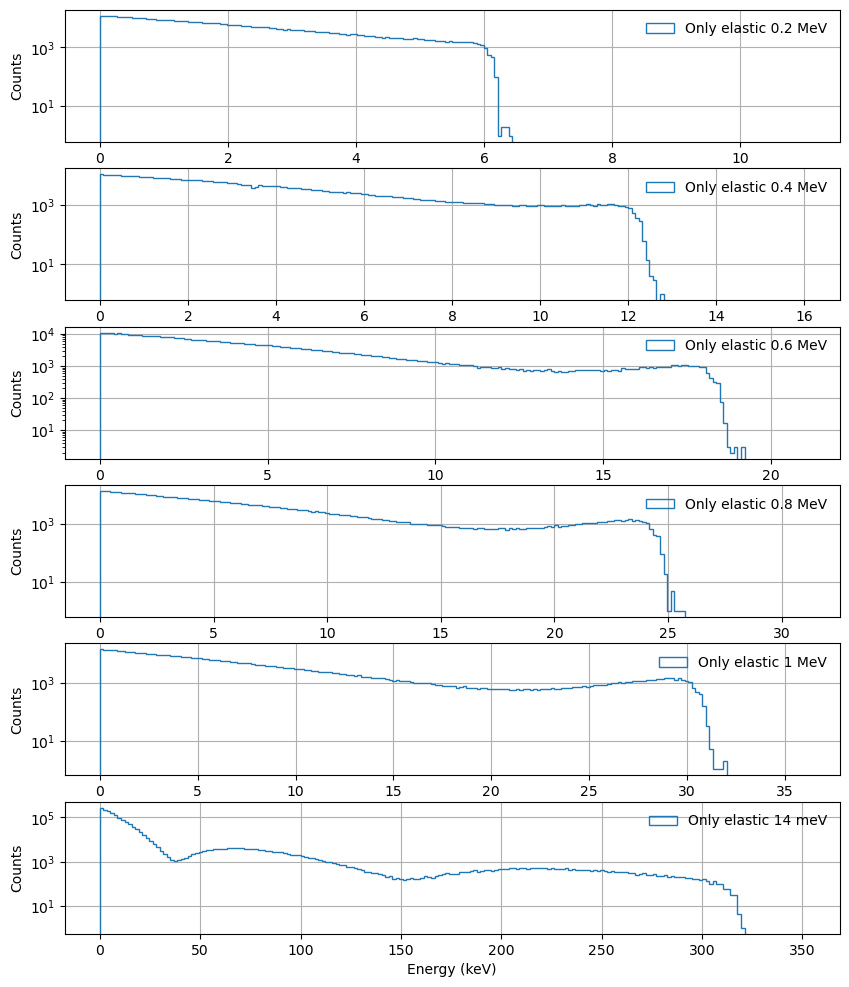

In [18]:

cut_main_elastic = lambda data: (
    (data['nelas'][:, 0] + data['nelas'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) &
    (ak.values_astype(data['type'], int) & 16 == 16)

    
)

cut_main_inelastic = lambda data: (
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
        
)

cut_main_ncap = lambda data: (
    (data['ncap'][:, 0] + data['ncap'][:, 1] == 1)  &
    (data["ndet"][:, 0] + data["ndet"][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1)
   
)


cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670)

# run_394 for 1 MeV, run_402 for 1 MeV from FV for 10m events run_405
elastic_neutron_1m = Geant4Analyzer("run_405", first_only=False)
# run_398 for 1 MeV, run_403 for 14 MeV from FV for 10m events run_406
elastic_neutron_14m = Geant4Analyzer("run_406", first_only=False)

elastic_neutron_02m = Geant4Analyzer("run_407", first_only=False)
elastic_neutron_04m=Geant4Analyzer("run_408", first_only=False)
elastic_neutron_06m = Geant4Analyzer("run_409", first_only=False)
elastic_neutron_08m= Geant4Analyzer("run_410", first_only=False)


elastic_neutron_1m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_14m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_02m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_04m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_06m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)
elastic_neutron_08m.preprocess_data(cut=cut_main_elastic, cut_hit=cut_hit_main)

fig , axs = plt.subplots(6,1 , figsize=(10,12))

elastic_neutron_02m.plot_histogram('eh', bins=200, ax=axs[0],label="Only elastic 0.2 MeV" , show=True, range=(0, 10 + 1))
elastic_neutron_04m.plot_histogram('eh', bins=200, ax=axs[1],label="Only elastic 0.4 MeV" , show=True, range=(0, 15 + 1))
elastic_neutron_06m.plot_histogram('eh', bins=200, ax=axs[2],label="Only elastic 0.6 MeV" , show=True, range=(0, 20 + 1))
elastic_neutron_08m.plot_histogram('eh', bins=200, ax=axs[3],label="Only elastic 0.8 MeV" , show=True, range=(0, 30 + 1))

elastic_neutron_1m.plot_histogram('eh', bins=200, ax=axs[4],label="Only elastic 1 MeV" , show=True, range=(0, 35 + 1))
elastic_neutron_14m.plot_histogram('eh', bins=200, ax=axs[5],label="Only elastic 14 meV" , show=True, range=(0, 350 + 1))

axs[1].grid(True)
axs[1].set_yscale("log")

axs[0].grid(True)
axs[0].set_yscale("log")

axs[2].grid(True)
axs[2].set_yscale("log")

axs[3].grid(True)   
axs[3].set_yscale("log")

axs[4].grid(True)
axs[4].set_yscale("log")

axs[5].grid(True)
axs[5].set_yscale("log")


plt.show()

In [13]:
cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)

cut_main_neutron = lambda data: (
    (data['nelas'][:, 0] + data['nelas'][:, 1] == 1) &
    (data['ninelas'][:, 0] + data['ninelas'][:, 1] + data['ncap'][:, 0] + data['ncap'][:, 1]  == 0) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
)

# -----------------------------------------------------------------------------------------------
std_neutron_02m = Geant4Analyzer("run_477", first_only=True)
std_neutron_02m.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

std_neutron_05m = Geant4Analyzer("run_478", first_only=True)
std_neutron_05m.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

std_neutron_1m = Geant4Analyzer("run_479", first_only=True)
std_neutron_1m.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

std_neutron_5m = Geant4Analyzer("run_480", first_only=True)
std_neutron_5m.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

std_neutron_14m = Geant4Analyzer("run_481", first_only=True)
std_neutron_14m.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)
# -----------------------------------------------------------------------------------------------
fast_02 = Geant4Analyzer("run_482", first_only=True)
fast_02.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

fast_05 = Geant4Analyzer("run_483", first_only=True)
fast_05.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

fast_1 = Geant4Analyzer("run_484", first_only=True)
fast_1.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

fast_5 = Geant4Analyzer("run_485", first_only=True)
fast_5.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)

fast_14 = Geant4Analyzer("run_486", first_only=True)
fast_14.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)
# -----------------------------------------------------------------------------------------------
std_no_EM_02 = Geant4Analyzer("run_488", first_only=True)
std_no_EM_02.preprocess_data(cut=cut_main_neutron, cut_hit=cut_hit_main)


clear_output()


integral Standard 0.2 MeV= 5846.0
integral Fast 0.2 MeV= 7873.241888829974
integral Standard 0.5 MeV= 4662.0
integral Fast 0.5 MeV= 7210.652456702209
integral Standard 1 MeV= 3425.0
integral Fast 1 MeV= 5462.104886978894
integral Standard 5 MeV= 3244.0
integral Fast 5 MeV= 5883.282388816492
integral Standard 14 MeV= 2438.0
integral Fast 14 MeV= 6123.754115350762


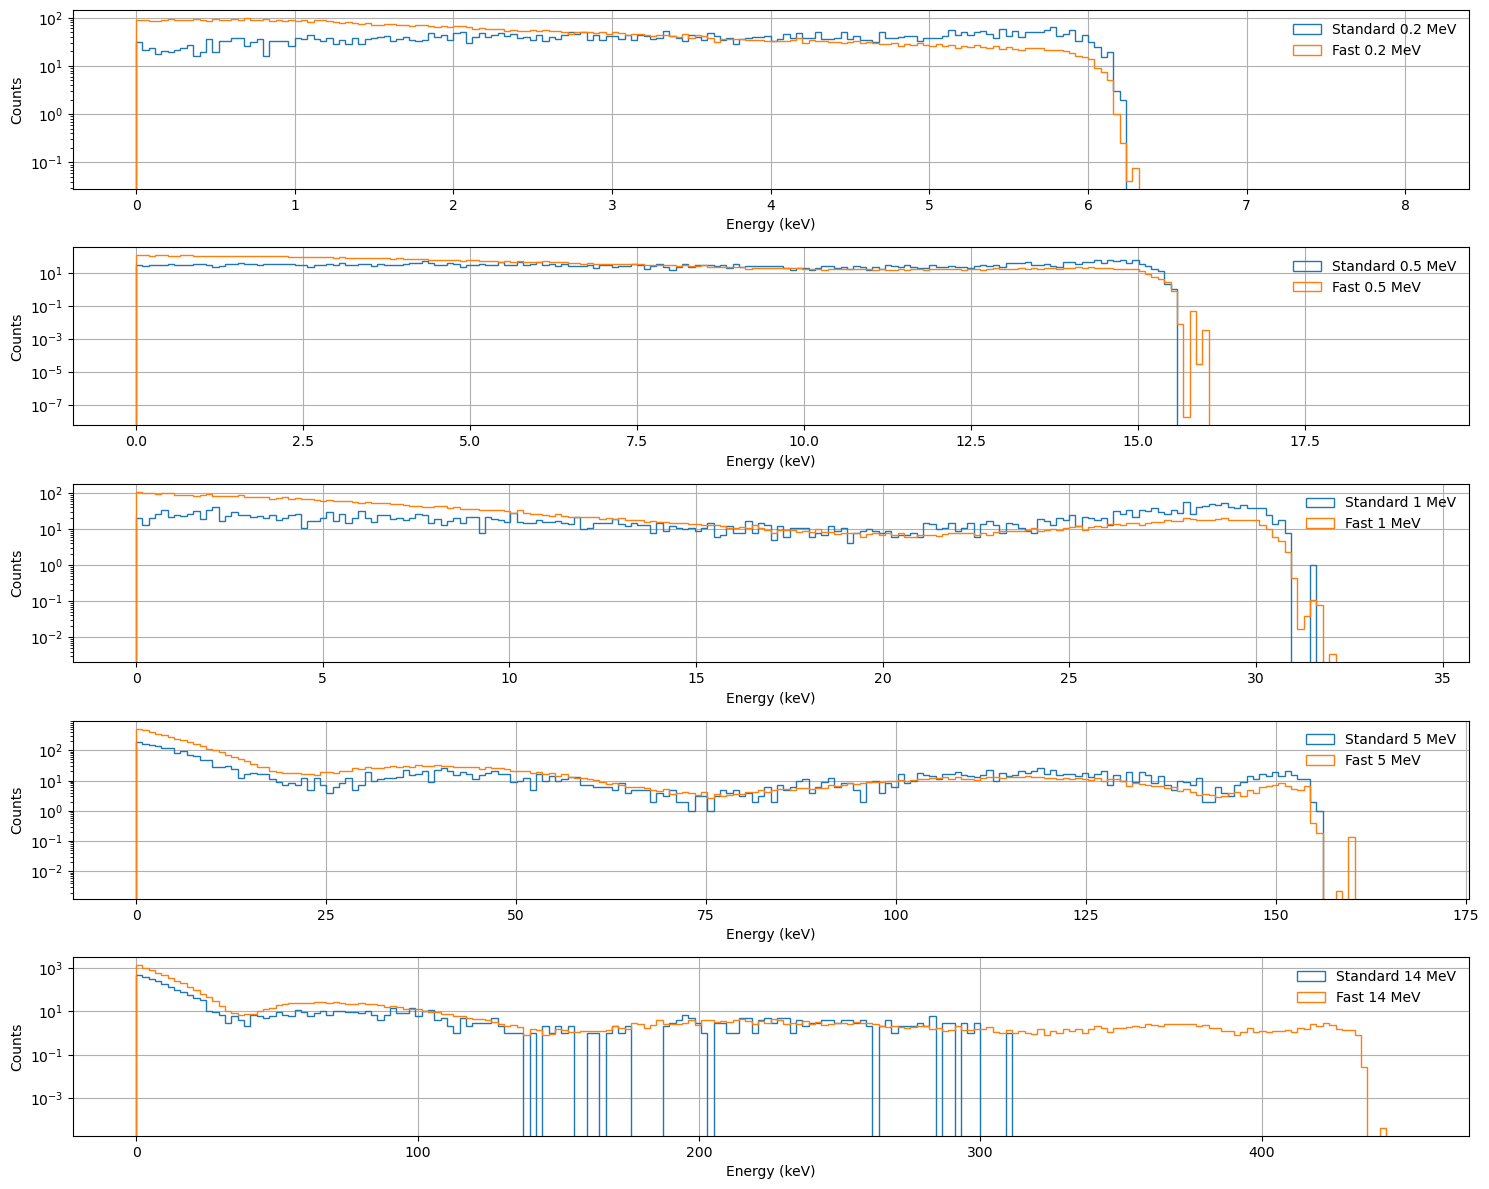

In [15]:
fig , axs = plt.subplots(5,1 , figsize=(15,12))

#plot all the energies, with fast and standard to compare
std_neutron_02m.plot_histogram('eh', bins=200, ax=axs[0],label="Standard 0.2 MeV" , show=True, range=(0, 7 + 1))
fast_02.plot_histogram('eh', bins=200, ax=axs[0],label="Fast 0.2 MeV" , show=True, range=(0, 7 + 1))

std_neutron_05m.plot_histogram('eh', bins=200, ax=axs[1],label="Standard 0.5 MeV" , show=True, range=(0, 18 + 1))
fast_05.plot_histogram('eh', bins=200, ax=axs[1],label="Fast 0.5 MeV" , show=True, range=(0, 18 + 1))

std_neutron_1m.plot_histogram('eh', bins=200, ax=axs[2],label="Standard 1 MeV" , show=True, range=(0, 33 + 1))
fast_1.plot_histogram('eh', bins=200, ax=axs[2],label="Fast 1 MeV" , show=True, range=(0, 33 + 1))

std_neutron_5m.plot_histogram('eh', bins=200, ax=axs[3],label="Standard 5 MeV" , show=True, range=(0, 166 + 1))
fast_5.plot_histogram('eh', bins=200, ax=axs[3],label="Fast 5 MeV" , show=True, range=(0, 166 + 1))

std_neutron_14m.plot_histogram('eh', bins=200, ax=axs[4],label="Standard 14 MeV" , show=True, range=(0, 450 + 1))
fast_14.plot_histogram('eh', bins=200, ax=axs[4],label="Fast 14 MeV" , show=True, range=(0, 450 + 1))

for ax in axs:
    ax.grid(True)
    ax.set_yscale("log")
    
plt.tight_layout()
plt.show()

['ev;1', 'gam;1', 'neutron;1', 'proc_names;1', 'diff_xsec;1', 'cost;1', 'proc;1']
{'Process Name': array(['neutron', 'Transportation', 'hadElastic', 'Xe134', 'ionIoni',
       'Radioactivation', 'Xe131', 'NoProcess', 'Xe132', 'Xe129', 'Xe136',
       'Xe128', 'Xe130', 'Cr52', 'Fe56', 'N14', 'Ni58', 'Fe54', 'Fe57',
       'O16', 'Xe124', 'Cr53', 'Ni60', 'Cr50', 'Cr54', 'Ar40', 'Xe126',
       'Ni64', 'Ni62', 'Fe58', 'Ni61', 'C12', 'N15'], dtype=object), 'Bin Index': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33],
      dtype=int32)}
dict_keys(['Process Name', 'Bin Index'])


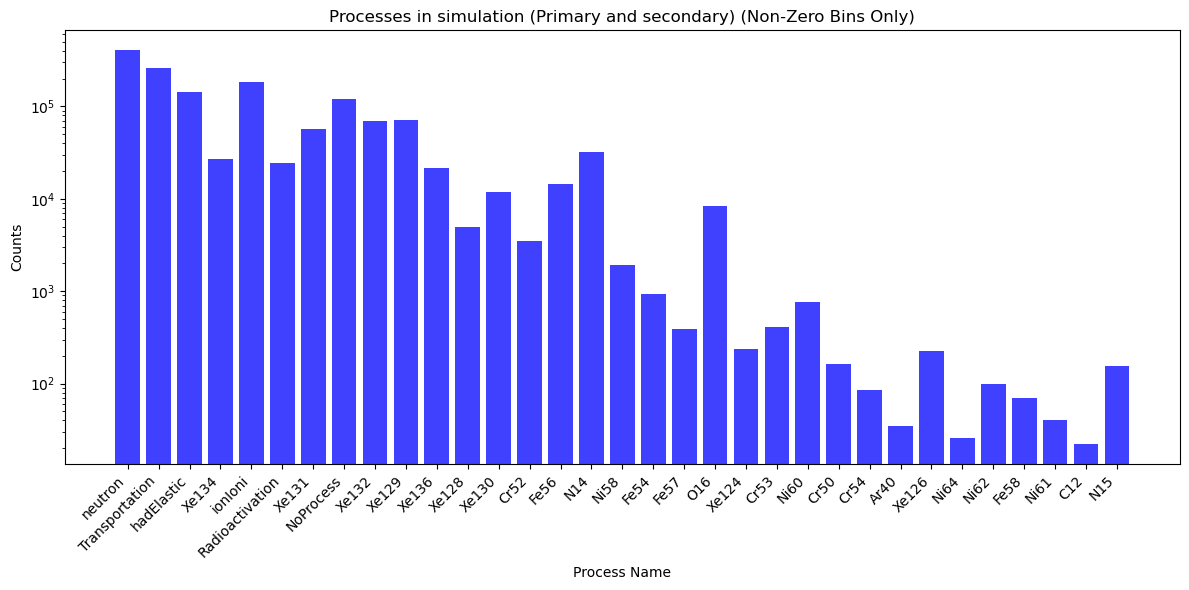

In [55]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 

# Open the ROOT file
file2 = uproot.open(manager.get_output_root_files("run_461")[0])
print(file2.keys())  # Print available trees

# Load histogram
hist = file2["proc"]
bin_counts = hist.values()
bin_edges = hist.axis().edges()

# Load process name mapping if available
if "proc_names" in file2:
    proc_data = file2["proc_names"].arrays(library="np")
    print(proc_data)
    print(proc_data.keys())
    # Convert to dictionary (check correct column names)
    process_map = dict(zip(proc_data["Bin Index"], proc_data["Process Name"]))
else:
    print("Warning: proc_names not found in ROOT file!")
    process_map = {}

# Get valid (non-zero) bins
nonzero_indices = np.where(bin_counts > 0)[0]
nonzero_counts = bin_counts[nonzero_indices]

# Assign labels (ensure correct bin mapping)
bin_labels = [process_map.get(int(bin_edges[i]), f"Unknown {int(bin_edges[i])}") for i in nonzero_indices]

# Plot non-zero bins only
plt.figure(figsize=(12, 6))
plt.bar(bin_labels, nonzero_counts, log=True, align='center', alpha=0.75, color="blue")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.xlabel("Process Name")
plt.ylabel("Counts")
plt.title("Processes in simulation (Primary and secondary) (Non-Zero Bins Only)")

plt.tight_layout()

plt.show()